In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('/Users/vicram/Downloads/student-por.csv')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
print('Missing Values')
print(df.isnull().sum())

Missing Values
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [11]:
print("Number of Duplicate Rows:")
print(df.duplicated().sum())

Number of Duplicate Rows:
0


In [13]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:")
print(df.shape)


Dataset Shape After Removing Duplicates:
(649, 33)


In [15]:
print("Data Types:")
print(df.dtypes)

Data Types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [17]:
numeric_columns = df.select_dtypes(include='number').columns

print("Numerical Columns:")
print(numeric_columns)

Numerical Columns:
Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')


In [19]:
categorical_columns = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')


In [21]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

df_encoded.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,0,4,3,2,2,...,True,False,True,False,False,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,False,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,False,False,True,True,False,False


In [23]:
print("Original Shape:", df.shape)
print("Encoded Shape:", df_encoded.shape)

Original Shape: (649, 33)
Encoded Shape: (649, 42)


In [25]:
df['Average_Grade'] = (
    df['G1'] + df['G2'] + df['G3']
) / 3

df[['G1', 'G2', 'G3', 'Average_Grade']].head()

,G1,G2,G3,Average_Grade
0,0,11,11,7.333333
1,9,11,11,10.333333
2,12,13,12,12.333333
3,14,14,14,14.000000
4,11,13,13,12.333333


In [27]:
df['Performance'] = pd.cut(
    df['Average_Grade'],
    bins=[0, 9.99, 13.99, 20],
    labels=[
        'Poor',
        'Average',
        'Good'
    ]
)

df[['G1', 'G2', 'G3', 'Average_Grade', 'Performance']].head(10)

,G1,G2,G3,Average_Grade,Performance
0,0,11,11,7.333333,Poor
1,9,11,11,10.333333,Average
2,12,13,12,12.333333,Average
3,14,14,14,14.000000,Good
4,11,13,13,12.333333,Average
5,12,12,13,12.333333,Average
6,13,12,13,12.666667,Average
7,10,13,13,12.000000,Average
8,15,16,17,16.000000,Good
9,12,12,13,12.333333,Average


In [29]:
print("Performance Category Count:")
print(df['Performance'].value_counts())

Performance Category Count:
Performance
Average    355
Poor       157
Good       137
Name: count, dtype: int64


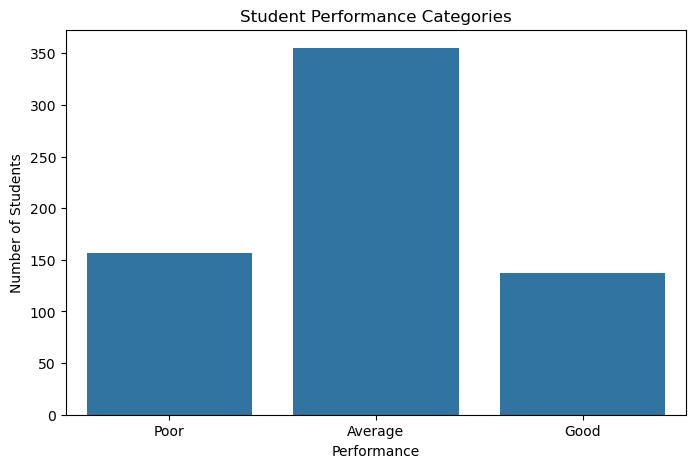

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Performance'
)

plt.title('Student Performance Categories')
plt.xlabel('Performance')
plt.ylabel('Number of Students')

plt.show()

In [33]:
print("Average Grade:", round(df['Average_Grade'].mean(), 2))
print("Highest Average Grade:", round(df['Average_Grade'].max(), 2))
print("Lowest Average Grade:", round(df['Average_Grade'].min(), 2))

Average Grade: 11.63
Highest Average Grade: 18.67
Lowest Average Grade: 1.33


In [35]:
print("Final Dataset:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

Final Dataset:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  goout Dalc  Walc  health  absences  G1  G2  G3 Average_Grade Performance  
0     4    1     1       3         4   0  11  11      7.333333        Poor  
1     3    1     1       3         2   9  11  11     10.333333     Average  
2     2    2     3       3         6  12  13  12     12.333333     Average  
3     2    1     1       5         0  14  14  14     14.000000        Good  
4     2    1     2       5         0  11  13  13     12.333333     Average  

[5 rows x 35 columns]

Dataset Shap